# Bayesian Change Point Analysis of Brent Oil Prices

## Objective

The objective of this notebook is to identify structural changes in Brent crude oil prices using Bayesian Change Point Analysis.

The model will detect periods where the statistical behavior of oil prices changed significantly and compare these changes with major historical events.

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load Prepared Data

The cleaned Brent oil price dataset generated during the EDA phase will be used for Bayesian Change Point Analysis.


In [2]:
# Load cleaned Brent oil dataset

file_path = "../data/processed/brent_cleaned.csv"

df = pd.read_csv(file_path)

# Convert Date column

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully!")
print(df.shape)

df.head()

Dataset loaded successfully!
(9927, 6)


,Date,Price,Rolling_Mean_30,Daily_Return,Rolling_Volatility_30,Log_Return
0,1987-05-20,18.63,NaN,NaN,NaN,NaN
1,1987-05-21,18.45,NaN,-0.009662,NaN,-0.009709
2,1987-05-22,18.55,NaN,0.005420,NaN,0.005405
3,1987-05-25,18.60,NaN,0.002695,NaN,0.002692
4,1987-05-26,18.63,NaN,0.001613,NaN,0.001612


## 2. Prepare Data for Bayesian Change Point Model

The Bayesian change point model will identify dates where the statistical behavior of Brent oil prices changed.

The price series will be used as the observed variable, and the model will estimate the most probable change point location.

# Prepare price data for modeling

# Remove missing values created by rolling calculations
model_data = df[["Date", "Price"]].dropna()

# Extract price values
prices = model_data["Price"].values

# Number of observations
n = len(prices)

print("Number of observations:", n)
print("First 5 prices:", prices[:5])

In [3]:
# Prepare price data for modeling

# Remove missing values created by rolling calculations
model_data = df[["Date", "Price"]].dropna()

# Extract price values
prices = model_data["Price"].values

# Number of observations
n = len(prices)

print("Number of observations:", n)
print("First 5 prices:", prices[:5])

Number of observations: 9927
First 5 prices: [18.63 18.45 18.55 18.6  18.63]


In [4]:
# Check PyMC installation

import pymc as pm

print("PyMC version:", pm.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC version: 6.1.0


## 3. Bayesian Change Point Model

A Bayesian change point model is used to identify the most probable point where the statistical behavior of Brent oil prices changes.

The model assumes:

- Before the change point: prices follow one distribution.
- After the change point: prices follow another distribution.

The model estimates:

- Change point location (τ)
- Average price before the change
- Average price after the change
- Uncertainty of the estimates


In [5]:
import pymc as pm
import numpy as np

# Use a smaller sample first for model testing
# (we will increase sampling later)

with pm.Model() as change_point_model:

    # Prior for change point location
    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=n-1
    )

    # Prior for mean prices before and after change point
    mu_before = pm.Normal(
        "mu_before",
        mu=np.mean(prices),
        sigma=50
    )

    mu_after = pm.Normal(
        "mu_after",
        mu=np.mean(prices),
        sigma=50
    )

    # Common standard deviation
    sigma = pm.HalfNormal(
        "sigma",
        sigma=50
    )

    # Switch between before and after change point
    mean_price = pm.math.switch(
        tau >= np.arange(n),
        mu_before,
        mu_after
    )

    # Likelihood
    observed = pm.Normal(
        "observed",
        mu=mean_price,
        sigma=sigma,
        observed=prices
    )

print("Bayesian change point model created successfully!")

Bayesian change point model created successfully!


In [6]:
# Run Bayesian sampling

with change_point_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        cores=1,
        random_seed=42
    )

print("Sampling completed successfully!")

Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_before, mu_after, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 8 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling completed successfully!


In [7]:
# Display model summary

import arviz as az

az.summary(trace, var_names=["tau", "mu_before", "mu_after", "sigma"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,4520.4,3.1,4500,4500,500,446,1.00,0.14,0.1
mu_before,21.43,0.263,21,22,2074,1222,1.00,0.0058,0.0041
mu_after,76.27,0.26,76,77,2643,1530,1.00,0.0051,0.0037
sigma,18.103,0.126,18,18,2517,1577,1.00,0.0025,0.0017


In [8]:
# Extract estimated change point index

change_point_index = int(trace.posterior["tau"].mean().values)

# Get corresponding date

change_point_date = model_data.iloc[change_point_index]["Date"]

print("Estimated Change Point Index:", change_point_index)
print("Estimated Change Point Date:", change_point_date)

Estimated Change Point Index: 4520
Estimated Change Point Date: 2005-02-23 00:00:00


## Change Point Interpretation

The Bayesian Change Point model identified a structural break in Brent crude oil prices around:

**23 February 2005**

At this point, the estimated average oil price changed from approximately:

- **Before change point:** $21.43 per barrel

to:

- **After change point:** $76.27 per barrel

This indicates a significant shift in the price level of Brent crude oil.

The detected change point represents a period where the underlying behavior of the oil market changed. Possible contributing factors include increasing global oil demand, supply constraints, geopolitical uncertainty, and changing market expectations during the mid-2000s.


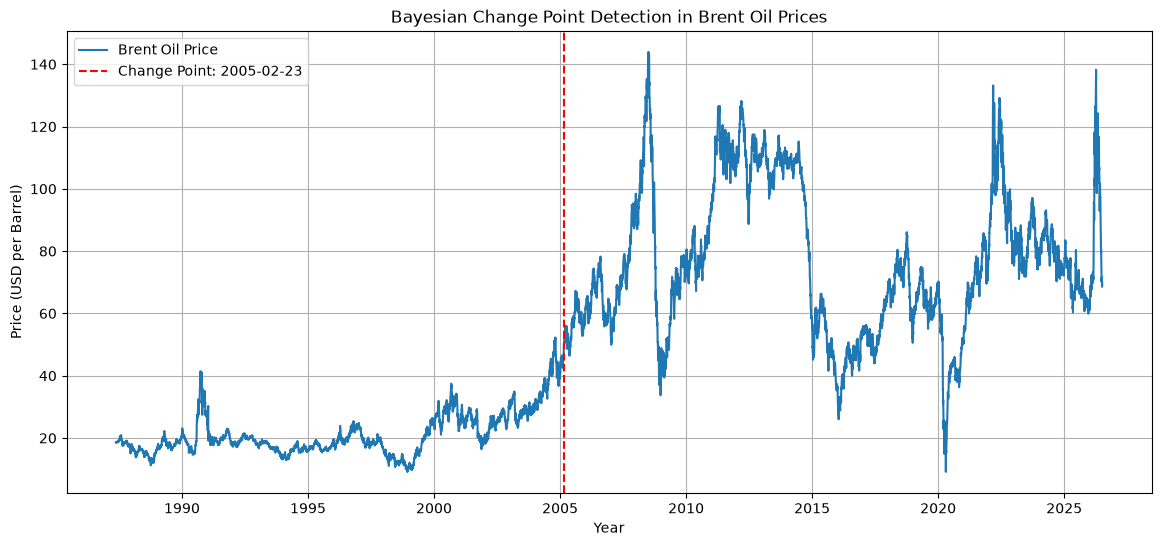

In [9]:
# Plot Brent prices with detected change point

plt.figure(figsize=(14,6))

plt.plot(
    model_data["Date"],
    model_data["Price"],
    label="Brent Oil Price"
)

plt.axvline(
    change_point_date,
    color="red",
    linestyle="--",
    label=f"Change Point: {change_point_date.date()}"
)

plt.title("Bayesian Change Point Detection in Brent Oil Prices")
plt.xlabel("Year")
plt.ylabel("Price (USD per Barrel)")

plt.legend()
plt.grid(True)

plt.show()

## 4. Compare Change Point with Historical Events

The detected Bayesian change point will be compared with major historical events affecting the global oil market.

This helps validate whether the identified structural break aligns with known market changes.

In [10]:
# Load historical events dataset

events = pd.read_csv("../data/processed/events.csv")

events["Date"] = pd.to_datetime(events["Date"])

events

,Date,Event,Category,Expected_Impact
0,1990-08-02,Iraq invades Kuwait,Geopolitical,Increase
1,1991-01-17,Operation Desert Storm begins,Geopolitical,Increase
2,1997-07-02,Asian Financial Crisis,Economic,Decrease
3,2001-09-11,September 11 attacks,Geopolitical,Decrease
4,2003-03-20,Iraq War begins,Geopolitical,Increase
5,2008-09-15,Global Financial Crisis (Lehman collapse),Economic,Decrease
6,2010-12-18,Arab Spring begins,Geopolitical,Increase
7,2011-02-17,Libyan Civil War,Geopolitical,Increase
8,2014-11-27,OPEC decides not to cut production,OPEC,Decrease
9,2016-11-30,OPEC production cut agreement,OPEC,Increase


In [11]:
# Find the closest historical event to the detected change point

events["Date_Difference"] = abs(
    (events["Date"] - change_point_date).dt.days
)

closest_event = events.sort_values(
    "Date_Difference"
).iloc[0]

closest_event

Date               2003-03-20 00:00:00
Event                  Iraq War begins
Category                  Geopolitical
Expected_Impact               Increase
Date_Difference                    706
Name: 4, dtype: object

In [12]:
# Display the difference in days

print(
    "Detected change point:",
    change_point_date.date()
)

print(
    "Closest event:",
    closest_event["Event"]
)

print(
    "Event date:",
    closest_event["Date"].date()
)

print(
    "Days difference:",
    closest_event["Date_Difference"]
)

Detected change point: 2005-02-23
Closest event: Iraq War begins
Event date: 2003-03-20
Days difference: 706


## Change Point and Historical Event Comparison

The Bayesian Change Point model identified a structural break on **23 February 2005**.

The closest event in the historical event dataset was:

- **Event:** Iraq War begins
- **Date:** 20 March 2003
- **Difference:** 706 days

Although the detected change point does not directly coincide with a single major geopolitical event, the period represents a broader transition in the global oil market.

Possible contributing factors include:

- Increasing global oil demand, particularly from emerging economies.
- Supply constraints and concerns about future production capacity.
- Continued geopolitical uncertainty following conflicts in major oil-producing regions.
- Changing expectations among oil market participants.

This demonstrates that Bayesian change point analysis can identify structural changes that may result from multiple interacting economic and geopolitical factors rather than a single event.